## Chocolate Sales
---
format: 
    html:
        page-layout: full
        embed_resources: false
        grid: 
            body-width: 800px
            fontsize: 18pt
echo: true
warning: false
toc: True
---

![chocolate gold](https://images.pexels.com/photos/65882/chocolate-dark-coffee-confiserie-65882.jpeg)
<sup>Pixabay, pexels.com</sup>

In [15]:
# | echo: false
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Image
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error


## Cleaning Dataset

In [16]:
# | echo: false
or_df = pd.read_csv("Chocolate Sales (2).csv")
or_df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [17]:
# | echo: false
or_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [18]:
# removing "$"
or_df["Amount"] = (
    or_df["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
# converting date to datetime
or_df["Date"] = pd.to_datetime(or_df["Date"], dayfirst=True)

# creating date features
or_df["Year"] = or_df["Date"].dt.year
or_df["Month"] = or_df["Date"].dt.month
or_df["Month Label"] = or_df["Date"].dt.strftime("%Y-%m")
or_df["Quarter"] = "Q" + or_df["Date"].dt.quarter.astype(str)

or_df["Product"] = or_df["Product"].replace({
    'Smooth Sliky Salty': 'Smooth Silky Salty',
    'Drinking Coco': 'Drinking Choco'
})


In [19]:
# saving clean dataset
or_df.to_csv("chocolate_sales_clean.csv", index=False)

## Analysis

In [20]:
# | echo: false
df = pd.read_csv("chocolate_sales_clean.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Month Label,Quarter
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022,1,2022-01,Q1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022,8,2022-08,Q3
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022,7,2022-07,Q3
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022,4,2022-04,Q2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022,2,2022-02,Q1


In [21]:
# | echo: false
# converting date to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [22]:
# | echo: false
print(f" Sales Persons: {df['Sales Person'].unique()}\n")
print(f" Countries: {df['Country'].unique()}\n")
print(f" Products: {df['Product'].unique()}\n")
print(f" Range: {df['Date'].min()} - {df['Date'].max()}")

 Sales Persons: ['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']

 Countries: ['UK' 'India' 'Australia' 'New Zealand' 'USA' 'Canada']

 Products: ['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Silky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Choco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']

 Range: 2022-01-03 00:00:00 - 2024-08-31 00:00:00


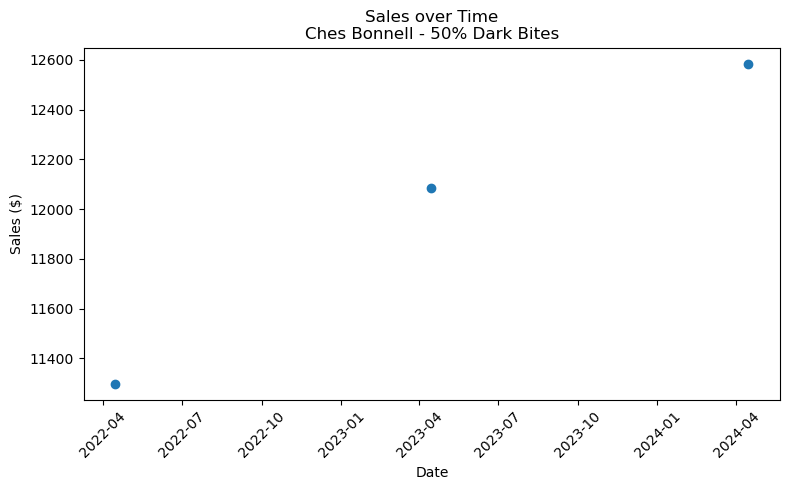

In [23]:
# | echo: false
salesman = "Ches Bonnell"
product = "50% Dark Bites"

# filter data
filtered = df[
    (df["Sales Person"] == salesman) &
    (df["Product"] == product)
]

# scatter plot
plt.figure(figsize=(8,5))
plt.scatter(filtered["Date"], filtered["Amount"])

plt.title(f"Sales over Time\n{salesman} - {product}")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display, clear_output, Image

df["Date"] = pd.to_datetime(df["Date"])

country_select = widgets.SelectMultiple(
    options=sorted(df["Country"].unique()),
    value=tuple(sorted(df["Country"].unique())[:2]),
    description="Country:",
    rows=6,
    layout=widgets.Layout(width="30%")
)

product_select = widgets.SelectMultiple(
    options=sorted(df["Product"].unique()),
    value=tuple(sorted(df["Product"].unique())[:3]),
    description="Product:",
    rows=8,
    layout=widgets.Layout(width="30%")
)

salesmen_select = widgets.SelectMultiple(
    options=[],
    value=(),
    description="Salesmen:",
    rows=10,
    layout=widgets.Layout(width="40%")
)

out = widgets.Output()

def get_base_filtered_data():
    return df[
        df["Country"].isin(country_select.value) &
        df["Product"].isin(product_select.value)
    ]

def get_plot_filtered_data():
    return df[
        df["Country"].isin(country_select.value) &
        df["Product"].isin(product_select.value) &
        df["Sales Person"].isin(salesmen_select.value)
    ]

def refresh_salesmen(change=None):
    filtered = get_base_filtered_data()
    names = sorted(filtered["Sales Person"].unique())

    salesmen_select.unobserve(update_plot, names="value")
    salesmen_select.options = names
    salesmen_select.value = tuple(names[:5])
    salesmen_select.observe(update_plot, names="value")

def update_plot(change=None):
    filtered = get_plot_filtered_data()

    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots(figsize=(12, 7))

        for person in salesmen_select.value:
            person_data = filtered[filtered["Sales Person"] == person]
            ax.scatter(
                person_data["Date"],
                person_data["Amount"],
                label=person,
                alpha=0.7
            )

        ax.set_title("Sales over Time")
        ax.set_xlabel("Month")
        ax.set_ylabel("Sales ($)")
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

        if salesmen_select.value and not filtered.empty:
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)

        display(Image(data=buf.read()))

country_select.observe(refresh_salesmen, names="value")
product_select.observe(refresh_salesmen, names="value")
salesmen_select.observe(update_plot, names="value")

controls = widgets.HBox([country_select, product_select, salesmen_select])
ui = widgets.VBox([controls, out])

display(ui)
refresh_salesmen()
update_plot()

In [25]:
# Base averages
product_avg = df.groupby("Product")["Amount"].mean()
person_avg = df.groupby("Sales Person")["Amount"].mean()
country_avg = df.groupby("Country")["Amount"].mean()
year_avg = df.groupby("Year")["Amount"].mean()


# Interaction averages
product_country_avg = df.groupby(["Product", "Country"])["Amount"].mean()
product_person_avg = df.groupby(["Product", "Sales Person"])["Amount"].mean()

global_avg = df["Amount"].mean()

# Map base features
df["product_avg"] = df["Product"].map(product_avg)
df["person_avg"] = df["Sales Person"].map(person_avg)
df["country_avg"] = df["Country"].map(country_avg)
df["year_avg"] = df["Year"].map(year_avg)


# Map interaction features

df["product_country_avg"] = df.apply(
    lambda row: product_country_avg.get((row["Product"], row["Country"]), global_avg),
    axis=1
)

df["product_person_avg"] = df.apply(
    lambda row: product_person_avg.get((row["Product"], row["Sales Person"]), global_avg),
    axis=1
)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# simple encoding
df_encoded = pd.get_dummies(df[[
    "Product",
    "Sales Person",
    "Country",
    "Year"
]])

X = df_encoded
y = np.log1p(df["Amount"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mae_pct = mae / y_test.mean()

print("MAE:", mae)
print(f"MAE %: {mae_pct:.2%}")

MAE: 0.48147509979698677
MAE %: 5.80%


In [32]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Year                              3282 non-null   int64
 1   Product_50% Dark Bites            3282 non-null   uint8
 2   Product_70% Dark Bites            3282 non-null   uint8
 3   Product_85% Dark Bars             3282 non-null   uint8
 4   Product_99% Dark & Pure           3282 non-null   uint8
 5   Product_After Nines               3282 non-null   uint8
 6   Product_Almond Choco              3282 non-null   uint8
 7   Product_Baker's Choco Chips       3282 non-null   uint8
 8   Product_Caramel Stuffed Bars      3282 non-null   uint8
 9   Product_Choco Coated Almonds      3282 non-null   uint8
 10  Product_Drinking Choco            3282 non-null   uint8
 11  Product_Eclairs                   3282 non-null   uint8
 12  Product_Fruit & Nut Bars          